# A/B Test Simulator & Analyser
### Does a win-back discount email bring customers back? A full experiment, from hypothesis to decision.

**Data:** [UCI Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail): 541,909 real transactions from a UK online gift wholesaler, Dec 2010 – Dec 2011.

**The catch:** this dataset contains no experiment. So this notebook *simulates* one on real customers: it randomly splits them into control and treatment, injects a **known** treatment effect, and then analyses the result blind, exactly as you would a live test. Knowing the ground truth lets us check that the statistics actually work: false-positive rates, power, and whether the final decision is right.

| Step | Section |
|---|---|
| Turn transactions into experiment units | 1. Data |
| State hypotheses, metrics, decision rules *before* looking at results | 2. Experiment design |
| How many customers do we need? What can we detect? | 3. Power analysis |
| Prove the tests behave (A/A tests, peeking) | 4. Validating the method |
| Randomise, check SRM and balance, run the tests | 5–6. Run & analyse |
| Ship or not, and what it's worth | 7. Recommendation |
| How often does this process reach the right call? | 8. Decision reliability |

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Markdown, display

from abtest import data, power as pw, simulate as sim, stats as st, viz
from abtest.report import ExperimentConfig, analyse_experiment, recommend, results_table, format_report

gbp = lambda x: f"−£{abs(x):,.0f}" if x < 0 else f"£{x:,.0f}"

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
FIG = Path("../reports/figures"); FIG.mkdir(parents=True, exist_ok=True)
RAW = Path("../data/raw")
SEED = 20  # a representative draw; Section 8 reruns the whole pipeline across 150 seeds per scenario

## 1. Data: from transactions to experiment units

A/B tests randomise **units**, and the unit here is the *customer* (an email goes to a person, not an invoice line). Randomising at a finer level than the treatment is delivered at would contaminate the groups.

Cleaning rules: drop rows with no `CustomerID` (can't be assigned to a group), cancellations (`InvoiceNo` starting with `C`), non-positive quantity/price, and exact duplicates.

In [2]:
raw = data.load_raw(RAW)
tx, funnel = data.clean_transactions(raw)
funnel_df = pd.Series(funnel, name="rows").to_frame()
funnel_df["removed"] = (-funnel_df["rows"].diff()).fillna(0).astype(int)
funnel_df.style.format("{:,}")

,rows,removed
raw_rows,"541,909",0
after_drop_missing_customer,"406,829","135,080"
after_drop_cancellations,"397,924","8,905"
after_drop_nonpositive_qty_price,"397,884",40
after_drop_duplicates,"392,692","5,192"


**Timeline.** The last complete quarter becomes the experiment window; everything before it is the pre-period.

- **Pre-period** (Dec 2010 – Aug 2011): defines who is *eligible* (bought at least once) and supplies covariates for balance checks and CUPED.
- **Test window** (Sep – Nov 2011, 91 days): where outcomes are measured. December 2011 has only 9 days of data, so it's excluded.

The scenario: on 1 September every eligible customer is randomised; treatment receives a *"We miss you — 10% off your next order"* email.

In [3]:
window = data.ExperimentWindow()
customers = data.build_customer_table(tx, window)
print(f"Eligible customers: {len(customers):,}   |   test window: {window.test_days} days")
customers.describe().T[["mean", "std", "min", "50%", "max"]]

Eligible customers: 3,317   |   test window: 91 days


,mean,std,min,50%,max
CustomerID,"15,284.1957","1,724.1849","12,346.0000","15,245.0000","18,287.0000"
pre_revenue,"1,575.9663","5,974.0117",2.9000,552.8000,"176,355.9400"
pre_orders,3.4408,5.5865,1.0000,2.0000,127.0000
pre_recency_days,92.1429,76.6875,0.0000,72.0000,273.0000
country_uk,0.9011,0.2986,0.0000,1.0000,1.0000
revenue,775.9892,"3,926.9301",0.0000,170.5600,"117,634.5300"
orders,1.4558,3.0431,0.0000,1.0000,86.0000
converted,0.5641,0.4960,0.0000,1.0000,1.0000
aov,435.9234,454.3183,3.3500,319.7600,"4,808.4800"


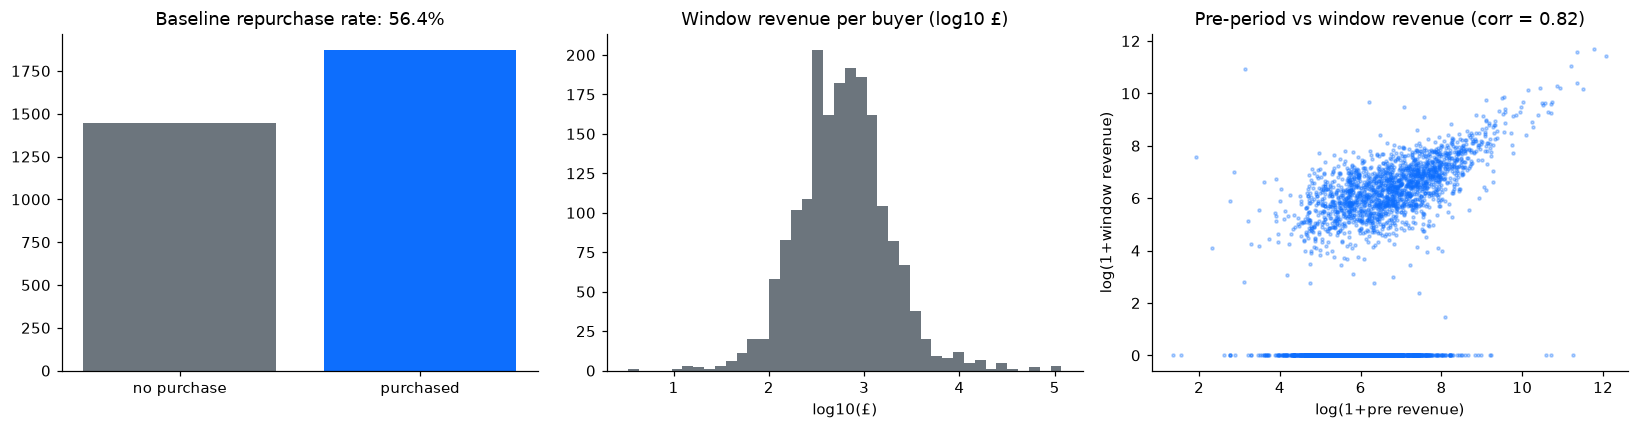

Top 1% of customers generate 35% of window revenue.


In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
p0 = customers["converted"].mean()
ax[0].bar(["no purchase", "purchased"], customers["converted"].value_counts().sort_index(), color=[viz.CONTROL, viz.TREATMENT])
ax[0].set_title(f"Baseline repurchase rate: {p0:.1%}")

buyers = customers.loc[customers.revenue > 0, "revenue"]
ax[1].hist(np.log10(buyers), bins=40, color=viz.CONTROL)
ax[1].set(title="Window revenue per buyer (log10 £)", xlabel="log10(£)")

ax[2].scatter(np.log1p(customers.pre_revenue), np.log1p(customers.revenue), s=4, alpha=.3, color=viz.TREATMENT)
rho = customers[["pre_revenue", "revenue"]].corr().iloc[0, 1]
ax[2].set(title=f"Pre-period vs window revenue (corr = {rho:.2f})", xlabel="log(1+pre revenue)", ylabel="log(1+window revenue)")
plt.tight_layout(); plt.savefig(FIG / "01_eda.png", bbox_inches="tight"); plt.show()

top1 = customers.revenue.nlargest(int(len(customers) * .01)).sum() / customers.revenue.sum()
print(f"Top 1% of customers generate {top1:.0%} of window revenue.")

Three things from EDA shape the whole design:

1. **Conversion is ~56%.** A high base rate makes a binary repurchase metric statistically efficient.
2. **Revenue is extremely heavy-tailed** (many customers are wholesalers). Mean-based revenue tests will be noisy, and a single whale landing in one arm can swing the result.
3. **Past spend strongly predicts future spend.** That's exactly the condition under which CUPED variance reduction pays off.

## 2. Experiment design (written before seeing results)

Pre-registering hypotheses and decision rules is what separates an experiment from a fishing trip.

| Role | Metric | Hypotheses | Test |
|---|---|---|---|
| **Primary** | Repurchase rate: share of eligible customers who order in the window | H₀: p_T = p_C  ·  H₁: p_T ≠ p_C | Two-proportion z-test; chi-square as cross-check |
| **Secondary** | Revenue per eligible customer (£) | H₀: μ_T = μ_C  ·  H₁: μ_T ≠ μ_C | Welch t-test with CUPED; Mann-Whitney and bootstrap as robustness checks |
| **Guardrail** | Average order value among buyers (£) | Must not fall more than 5% | Welch t-test |

**Parameters:** α = 0.05 (two-sided), target power = 80%, 50/50 split.
**Multiple testing:** the single pre-registered primary metric is tested at full α. The supporting metrics (secondary + guardrail) are **Holm-corrected** as a family. Correcting the primary too would silently cut power from 80% to roughly 67%.
Minimum practically significant lift: **+2pp** repurchase rate. Below that, the email isn't worth the discount cost.

**Decision rules** (implemented in `abtest.report.recommend`):
1. Sample-ratio mismatch → **INVALID**, don't interpret anything.
2. Primary significantly up and guardrail OK → **SHIP**.
3. Primary up but guardrail breached → **SHIP WITH CAUTION** only if revenue per customer is also significantly up; else **DO NOT SHIP**.
4. Primary significantly down → **DO NOT SHIP**.
5. Not significant and CI rules out +2pp → **DO NOT SHIP**. Not significant but CI still includes +2pp → **INCONCLUSIVE**.

## 3. Power analysis: what can this test detect?

Normally you pick an MDE and solve for sample size. Here the population is fixed (you can't email customers you don't have), so the real question is reversed: **given ~1,650 customers per arm, what's the smallest effect we can reliably detect?**

For a proportion with baseline $p$ and $n$ per arm:
$$\text{MDE} = (z_{1-\alpha/2} + z_{1-\beta})\sqrt{\frac{2p(1-p)}{n}}$$

In [5]:
n_arm = len(customers) // 2
sd_rev = customers.revenue.std()
mde_conv = pw.mde_proportions(p0, n_arm)
mde_rev = pw.mde_means(sd_rev, n_arm)
mde_rev_cuped = pw.mde_means(pw.cuped_sd(sd_rev, rho), n_arm)
cw = st.winsorize(customers, "revenue", 0.99)
mde_rev_w = pw.mde_means(cw.revenue_w.std(), n_arm)
rho_w = np.corrcoef(cw.pre_revenue.clip(upper=cw.pre_revenue.quantile(.99)), cw.revenue_w)[0, 1]
mde_rev_wc = pw.mde_means(pw.cuped_sd(cw.revenue_w.std(), rho_w), n_arm)

mean_rev = customers.revenue.mean()
pd.DataFrame({
    "metric": ["Repurchase rate", "Revenue / customer", "Revenue / customer + CUPED",
               "Revenue / customer, winsorised p99", "Winsorised + CUPED"],
    "baseline": [f"{p0:.1%}"] + [f"£{mean_rev:,.0f}"] * 2 + [f"£{cw.revenue_w.mean():,.0f}"] * 2,
    "MDE (abs)": [f"{mde_conv*100:.1f}pp", f"£{mde_rev:,.0f}", f"£{mde_rev_cuped:,.0f}", f"£{mde_rev_w:,.0f}", f"£{mde_rev_wc:,.0f}"],
    "MDE (relative)": [mde_conv / p0, mde_rev / mean_rev, mde_rev_cuped / mean_rev,
                       mde_rev_w / cw.revenue_w.mean(), mde_rev_wc / cw.revenue_w.mean()],
}).style.format({"MDE (relative)": "{:.0%}"}).hide(axis="index")

metric,baseline,MDE (abs),MDE (relative)
Repurchase rate,56.4%,4.8pp,9%
Revenue / customer,£776,£382,49%
Revenue / customer + CUPED,£776,£220,28%
"Revenue / customer, winsorised p99",£599,£122,20%
Winsorised + CUPED,£599,£76,13%


In [6]:
display(Markdown(f'''
**Reading this:** with the customers available, the test can detect a **~{mde_conv*100:.1f}pp** change in repurchase rate
({mde_conv/p0:.0%} relative), which is reasonable for a discount email. But raw revenue per customer needs a
**{mde_rev/mean_rev:.0%}** lift to be detectable, which is unrealistic.
CUPED cuts that to {mde_rev_cuped/mean_rev:.0%}, and winsorising plus CUPED to {mde_rev_wc/cw.revenue_w.mean():.0%}.

→ **Conversion is the right primary metric.** Revenue is reported, but the test is not powered to decide on it alone.
'''))


**Reading this:** with the customers available, the test can detect a **~4.8pp** change in repurchase rate
(9% relative), which is reasonable for a discount email. But raw revenue per customer needs a
**49%** lift to be detectable, which is unrealistic.
CUPED cuts that to 28%, and winsorising plus CUPED to 13%.

→ **Conversion is the right primary metric.** Revenue is reported, but the test is not powered to decide on it alone.


How many customers *would* we need for smaller effects? (This is the table you'd hand a stakeholder who asks for a "quick test".)

In [7]:
lifts = [0.01, 0.02, 0.03, 0.05, 0.08]
pd.DataFrame({
    "true lift": [f"+{l*100:.0f}pp" for l in lifts],
    "n per arm": [pw.sample_size_proportions(p0, l) for l in lifts],
    "total": [2 * pw.sample_size_proportions(p0, l) for l in lifts],
    "feasible with our population?": ["✅" if 2 * pw.sample_size_proportions(p0, l) <= len(customers) else "❌" for l in lifts],
}).style.hide(axis="index")

true lift,n per arm,total,feasible with our population?
+1pp,38492,76984,❌
+2pp,9592,19184,❌
+3pp,4248,8496,❌
+5pp,1517,3034,✅
+8pp,583,1166,✅


**Does the formula match reality?** Simulate hundreds of experiments with a known effect and count how often the test detects it.

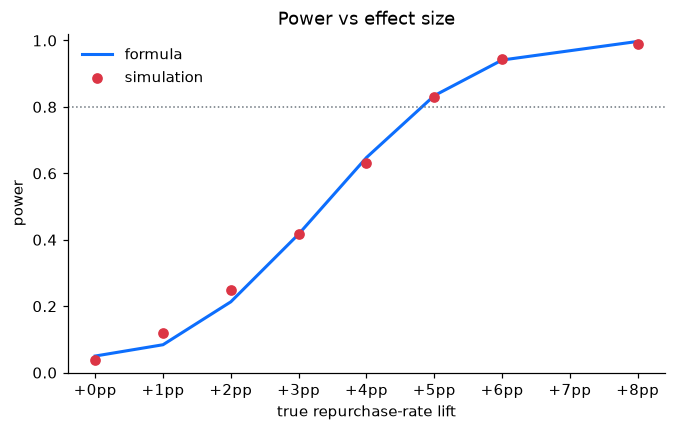

In [8]:
effects = np.array([0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.08])
theory = [pw.power_proportions(p0, e, n_arm) if e else 0.05 for e in effects]
empirical = [(sim.simulate_pvalues(customers, "converted", "proportion", n_sims=300, conversion_lift_abs=e, seed=i) < .05).mean()
             for i, e in enumerate(effects)]
fig, ax = plt.subplots(figsize=(7, 4))
viz.plot_power_curve(effects, theory, empirical, ax=ax, xlabel="true repurchase-rate lift",
                     fmt=lambda x: f"+{x*100:.0f}pp")
plt.savefig(FIG / "02_power_curve.png", bbox_inches="tight"); plt.show()

The simulated points track the analytical curve, so the power maths holds on this real, messy data.

## 4. Validating the method before trusting it

### 4a. A/A tests
Split customers randomly with **no** treatment, 1,000 times. If the pipeline is sound, p-values are uniform and about 5% come out "significant" by chance. A higher rate would mean a bug or a broken test assumption.

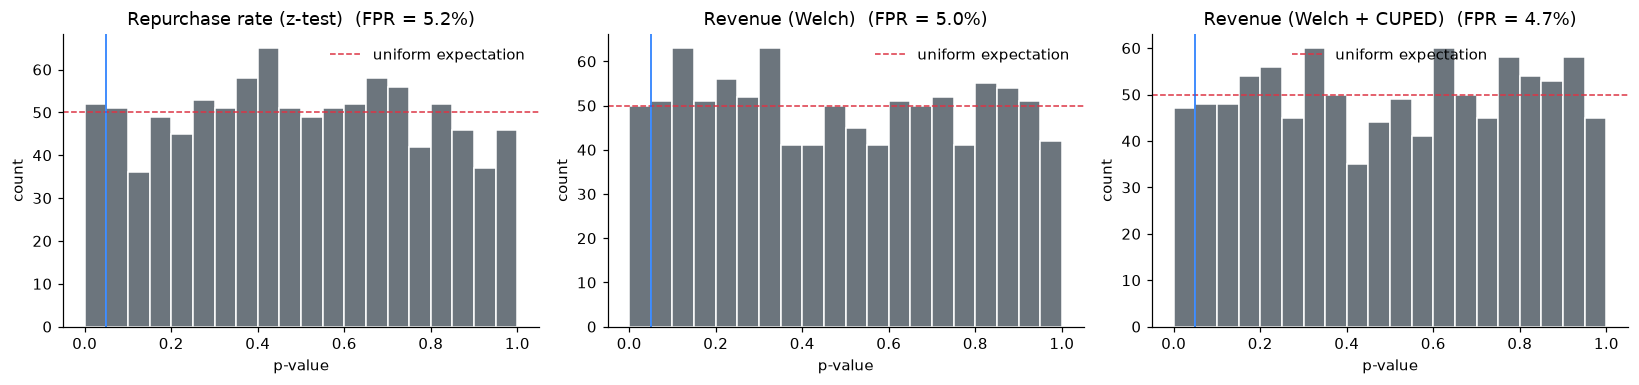

In [9]:
aa = {
    "Repurchase rate (z-test)": sim.simulate_pvalues(customers, "converted", "proportion", n_sims=1000, seed=1),
    "Revenue (Welch)": sim.simulate_pvalues(customers, "revenue", "welch", n_sims=1000, seed=2),
    "Revenue (Welch + CUPED)": sim.simulate_pvalues(customers, "revenue", "cuped", n_sims=1000, covariate="pre_revenue", seed=3),
}
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, (name, p) in zip(axes, aa.items()):
    viz.plot_pvalue_hist(p, ax=ax, title=name)
plt.tight_layout(); plt.savefig(FIG / "03_aa_tests.png", bbox_inches="tight"); plt.show()

All three sit close to the nominal 5%. The Welch test stays valid on heavy-tailed revenue at this sample size (it tends to be slightly *conservative*: it loses power, not correctness).

### 4b. Why you can't peek
A common real-world failure is to check results daily and stop as soon as p < 0.05. Simulating A/A tests with 10 interim looks shows what that does to the false-positive rate:

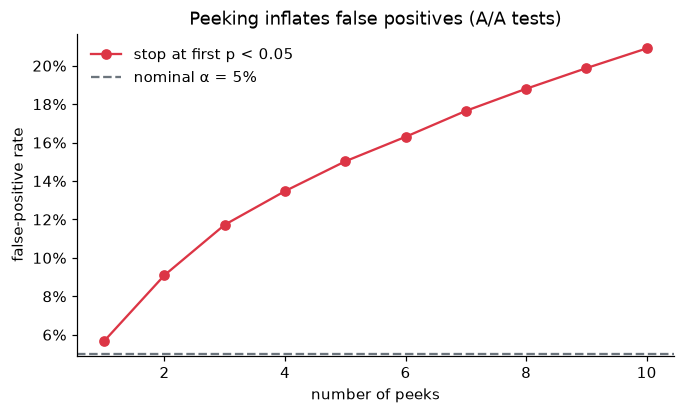

Single final look: 5.3%   |   Peeking 10 times: 20.9%


In [10]:
peek = sim.simulate_peeking(p=p0, n_per_group=n_arm, n_looks=10, n_sims=4000, seed=SEED)
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(range(1, 11), peek["fpr_by_look"], marker="o", color=viz.ACCENT, label="stop at first p < 0.05")
ax.axhline(0.05, color=viz.CONTROL, ls="--", label="nominal α = 5%")
ax.set(xlabel="number of peeks", ylabel="false-positive rate", title="Peeking inflates false positives (A/A tests)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}")); ax.legend(frameon=False)
plt.savefig(FIG / "04_peeking.png", bbox_inches="tight"); plt.show()
print(f"Single final look: {peek['fpr_single_look']:.1%}   |   Peeking 10 times: {peek['fpr_with_peeking']:.1%}")

So this analysis uses **one pre-planned look** at the end of the 91-day window. If early stopping were a business requirement, the fix is a sequential design (e.g. O'Brien-Fleming alpha spending), not ad-hoc peeking.

## 5. Run the experiment

**Ground truth injected** (hidden from the analysis below, used only to grade it at the end):
- The email raises repurchase probability by **+5pp**.
- The 10% discount lowers spend per buyer by **3%**.

Newly converted customers get order histories resampled from real treatment-group buyers, so they look like genuine customers.

In [11]:
TRUE_CONV_LIFT, TRUE_REV_MULT = 0.05, -0.03
df = sim.simulate_experiment(customers, TRUE_CONV_LIFT, TRUE_REV_MULT, seed=SEED)
df.groupby("group").agg(customers=("CustomerID", "size"), repurchase_rate=("converted", "mean"),
                        revenue_per_customer=("revenue", "mean"), aov=("aov", "mean"))

,customers,repurchase_rate,revenue_per_customer,aov
group,,,,
control,1636,0.5617,764.4045,438.4182
treatment,1681,0.6163,846.9995,428.9576


### 5a. Sample Ratio Mismatch check
Before looking at any outcome: did randomisation produce the split we intended? A failed SRM check invalidates everything downstream.

In [12]:
srm = st.srm_check(df)
pd.Series(srm, name="SRM check").to_frame().T

,control_n,treatment_n,chi2,p_value,srm_detected
SRM check,1636,1681,0.6105,0.4346,False


### 5b. Covariate balance
Randomisation should balance pre-period characteristics. Standardised mean difference (SMD) under 0.1 is the conventional threshold.

In [13]:
cfg = ExperimentConfig()
st.balance_table(df, cfg.balance_covariates)

,covariate,control_mean,treatment_mean,smd,balanced
0,pre_revenue,"1,592.6798","1,559.7002",-0.0055,True
1,pre_orders,3.2989,3.5788,0.0502,True
2,pre_recency_days,91.8692,92.4093,0.0070,True
3,country_uk,0.9034,0.8989,-0.0153,True


## 6. Analysis

In [14]:
res = analyse_experiment(df, cfg)
results_table(res)

,metric,test,control_value,treatment_value,abs_diff,rel_lift,ci_low,ci_high,p_value,significant
0,converted,two-proportion z-test,0.5617,0.6163,0.0546,0.0971,0.0211,0.0880,0.0014,True
1,converted,chi-square,0.5617,0.6163,0.0546,0.0971,0.0211,0.0880,0.0014,True
2,revenue,Welch t-test,764.4045,846.9995,82.5950,0.1081,-183.0006,348.1907,0.5421,False
3,revenue,Welch t-test + CUPED,764.4045,846.9995,100.0515,0.1309,-54.6862,254.7893,0.2050,False
4,revenue,Mann-Whitney U (median),153.4700,250.6674,97.1974,0.6333,43.4416,153.9398,0.0007,True
5,aov,Welch t-test,438.4182,428.9576,-9.4606,-0.0216,-50.0197,31.0985,0.6474,False


### 6a. Primary metric: repurchase rate

In [15]:
p, chi = res["primary"], res["primary_chi2"]
print(pd.crosstab(df.group, df.converted, margins=True).rename(columns={0: "no purchase", 1: "purchased"}), "\n")
print(f"z = {p.statistic:.3f} → z² = {p.statistic**2:.3f}  |  chi-square = {chi.statistic:.3f}  (identical, as expected for a 2x2 table)")
display(Markdown(f'''
Treatment repurchase rate **{p.treatment_value:.1%}** vs control **{p.control_value:.1%}**:
a lift of **{p.abs_diff*100:+.1f}pp** ({p.rel_lift:+.1%} relative), 95% CI **[{p.ci_low*100:+.1f}pp, {p.ci_high*100:+.1f}pp]**, p = {p.p_value:.2g}.

*Interpretation of the p-value:* if the email truly had no effect, a difference at least this large would occur
{"less than 0.1% of the time" if p.p_value < 0.001 else f"{p.p_value:.1%} of the time"} from random assignment alone.
It is **not** the probability that the email "doesn't work". The CI is the more useful number for the business: it gives the plausible range of the true lift.
'''))

converted  no purchase  purchased   All
group                                  
control            717        919  1636
treatment          645       1036  1681
All               1362       1955  3317 

z = 3.194 → z² = 10.200  |  chi-square = 10.200  (identical, as expected for a 2x2 table)



Treatment repurchase rate **61.6%** vs control **56.2%**:
a lift of **+5.5pp** (+9.7% relative), 95% CI **[+2.1pp, +8.8pp]**, p = 0.0014.

*Interpretation of the p-value:* if the email truly had no effect, a difference at least this large would occur
0.1% of the time from random assignment alone.
It is **not** the probability that the email "doesn't work". The CI is the more useful number for the business: it gives the plausible range of the true lift.


### 6b. Secondary metric: revenue per customer
One metric, four lenses. Each answers a slightly different question, and the disagreement between them is itself informative.

In [16]:
boot = st.bootstrap_test(df, "revenue", n_boot=5000, seed=SEED)
w = st.winsorize(df, "revenue", 0.99)
w_res = st.welch_ttest(w, "revenue_w", label="revenue (winsorised p99)")
rev_rows = [res["revenue_unadjusted"], boot, res["revenue"], w_res, res["revenue_mann_whitney"]]
pd.DataFrame([r.to_dict() for r in rev_rows])[["metric", "test", "control_value", "treatment_value", "abs_diff", "ci_low", "ci_high", "p_value", "significant"]]

,metric,test,control_value,treatment_value,abs_diff,ci_low,ci_high,p_value,significant
0,revenue,Welch t-test,764.4045,846.9995,82.5950,-183.0006,348.1907,0.5421,False
1,revenue,bootstrap (mean),764.4045,846.9995,82.5950,-176.5679,355.4802,0.5304,False
2,revenue,Welch t-test + CUPED,764.4045,846.9995,100.0515,-54.6862,254.7893,0.2050,False
3,revenue (winsorised p99),Welch t-test,575.4513,683.3295,107.8782,19.5773,196.1792,0.0167,True
4,revenue,Mann-Whitney U (median),153.4700,250.6674,97.1974,43.4416,153.9398,0.0007,True


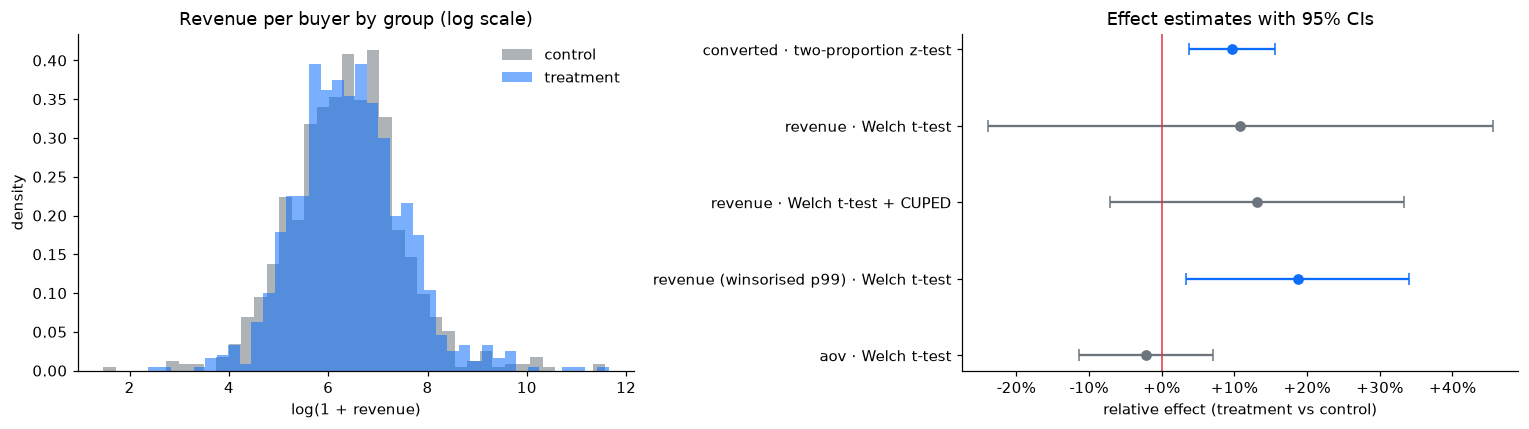


- **CUPED** uses pre-period revenue (corr = 0.81) to remove 66% of revenue variance.
  Because the covariate predates randomisation it can't be affected by the treatment, so the adjustment narrows the CI without biasing the estimate.
- **Winsorising** at the 99th percentile stops a handful of wholesalers dominating the mean, at the cost of estimating a slightly different quantity.
- **Mann-Whitney** tests whether treatment shifts the *distribution*. It's driven mostly by the extra converters (zeros becoming positive), not by spend per buyer.
- As the power analysis predicted, the revenue estimates are imprecise: the CIs are wide relative to the effect.


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
viz.plot_group_distributions(df.query("revenue > 0"), "revenue", ax=ax[0])
ax[0].set_title("Revenue per buyer by group (log scale)")
viz.plot_ci_forest([res["primary"], res["revenue_unadjusted"], res["revenue"], w_res, res["guardrail"]], ax=ax[1])
plt.tight_layout(); plt.savefig(FIG / "05_results.png", bbox_inches="tight"); plt.show()

cu = res["cuped"]
display(Markdown(f'''
- **CUPED** uses pre-period revenue (corr = {cu["corr"]:.2f}) to remove {cu["variance_reduction"]:.0%} of revenue variance.
  Because the covariate predates randomisation it can't be affected by the treatment, so the adjustment narrows the CI without biasing the estimate.
- **Winsorising** at the 99th percentile stops a handful of wholesalers dominating the mean, at the cost of estimating a slightly different quantity.
- **Mann-Whitney** tests whether treatment shifts the *distribution*. It's driven mostly by the extra converters (zeros becoming positive), not by spend per buyer.
- As the power analysis predicted, the revenue estimates are imprecise: the CIs are wide relative to the effect.
'''))

### 6c. Guardrail: average order value

In [18]:
g = res["guardrail"]
display(Markdown(f'''
AOV: control £{g.control_value:,.0f} vs treatment £{g.treatment_value:,.0f} ({g.rel_lift:+.1%}),
95% CI [{gbp(g.ci_low)}, {gbp(g.ci_high)}] per order, p = {g.p_value:.3f}.
Guardrail threshold is −5%: **{"breached" if (g.significant and g.rel_lift < cfg.guardrail_tolerance) else "not breached"}**.
'''))


AOV: control £438 vs treatment £429 (-2.2%),
95% CI [−£50, £31] per order, p = 0.647.
Guardrail threshold is −5%: **not breached**.


### 6d. Multiple-comparison correction
The primary metric was pre-registered alone, so it's judged at α = 0.05. The two supporting metrics are corrected together with Holm's step-down procedure, which controls the family-wise error rate and is uniformly more powerful than Bonferroni.

In [19]:
res["corrected"][["metric", "test", "p_value", "p_holm", "significant_holm"]]

,metric,test,p_value,p_holm,significant_holm
0,revenue,Welch t-test + CUPED,0.2050,0.4099,False
1,aov,Welch t-test,0.6474,0.6474,False


## 7. Business recommendation

In [20]:
rec = recommend(res)
imp = rec["impact"]
print(format_report(res, rec))

=== Win-back email with 10% discount ===
Units: 1,636 control / 1,681 treatment (SRM p=0.435)
Balance: 4/4 covariates |SMD| < 0.1

   metric                    test  control_value  treatment_value  abs_diff  rel_lift    ci_low  ci_high  p_value  significant
converted   two-proportion z-test         0.5617           0.6163    0.0546    0.0971    0.0211   0.0880   0.0014         True
converted              chi-square         0.5617           0.6163    0.0546    0.0971    0.0211   0.0880   0.0014         True
  revenue            Welch t-test       764.4045         846.9995   82.5950    0.1081 -183.0006 348.1907   0.5421        False
  revenue    Welch t-test + CUPED       764.4045         846.9995  100.0515    0.1309  -54.6862 254.7893   0.2050        False
  revenue Mann-Whitney U (median)       153.4700         250.6674   97.1974    0.6333   43.4416 153.9398   0.0007         True
      aov            Welch t-test       438.4182         428.9576   -9.4606   -0.0216  -50.0197  31.0985   

In [21]:
p, rv = res["primary"], res["revenue"]
extra_buyers = p.abs_diff * len(customers)
display(Markdown(f'''
### Verdict: **{rec["verdict"]}**

**What happened.** The win-back email lifted the 91-day repurchase rate from {p.control_value:.1%} to {p.treatment_value:.1%}
({p.abs_diff*100:+.1f}pp, 95% CI {p.ci_low*100:+.1f} to {p.ci_high*100:+.1f}pp). Rolled out to all {len(customers):,} eligible customers,
that's roughly **{extra_buyers:,.0f} additional returning customers per quarter**.

**Revenue.** The CUPED point estimate is {gbp(rv.abs_diff)} per eligible customer per quarter
(≈ {gbp(imp["total"])} across the base), but the 95% CI runs from {gbp(rv.ci_low)} to {gbp(rv.ci_high)} per customer
(p = {rv.p_value:.2f}).
The test was powered for conversion, not revenue, so the revenue figure is directional only.

**Guardrail.** AOV moved {res["guardrail"].rel_lift:+.1%} (p = {res["guardrail"].p_value:.2f}): no evidence the discount made buyers spend meaningfully less per order.

**Recommendations**
1. {"Roll out the win-back email to all lapsed-eligible customers." if rec["verdict"] == "SHIP" else "Follow the verdict above before any rollout."}
2. Keep a **5–10% holdout** after launch to keep measuring incremental revenue over several quarters, since a single quarter can't resolve it.
3. Next test: vary the **discount depth** (5% vs 10% vs free shipping) to find the cheapest incentive that drives the same repurchase lift.
4. Segment follow-up: check whether the effect is concentrated in recently-lapsed vs long-dormant customers (pre-register this; don't go fishing).
'''))


### Verdict: **SHIP**

**What happened.** The win-back email lifted the 91-day repurchase rate from 56.2% to 61.6%
(+5.5pp, 95% CI +2.1 to +8.8pp). Rolled out to all 3,317 eligible customers,
that's roughly **181 additional returning customers per quarter**.

**Revenue.** The CUPED point estimate is £100 per eligible customer per quarter
(≈ £331,871 across the base), but the 95% CI runs from −£55 to £255 per customer
(p = 0.20).
The test was powered for conversion, not revenue, so the revenue figure is directional only.

**Guardrail.** AOV moved -2.2% (p = 0.65): no evidence the discount made buyers spend meaningfully less per order.

**Recommendations**
1. Roll out the win-back email to all lapsed-eligible customers.
2. Keep a **5–10% holdout** after launch to keep measuring incremental revenue over several quarters, since a single quarter can't resolve it.
3. Next test: vary the **discount depth** (5% vs 10% vs free shipping) to find the cheapest incentive that drives the same repurchase lift.
4. Segment follow-up: check whether the effect is concentrated in recently-lapsed vs long-dormant customers (pre-register this; don't go fishing).


### Grading against the ground truth
Because this was a simulation, we can check the analysis against what actually happened.

In [22]:
pd.DataFrame({
    "quantity": ["Repurchase lift", "Spend per buyer"],
    "true (injected)": [f"+{TRUE_CONV_LIFT*100:.1f}pp", f"{TRUE_REV_MULT:+.0%}"],
    "estimated": [f"{p.abs_diff*100:+.1f}pp", f"{res['guardrail'].rel_lift:+.1%} (AOV)"],
    "truth inside 95% CI?": [p.ci_low <= TRUE_CONV_LIFT <= p.ci_high,
                             res["guardrail"].ci_low <= TRUE_REV_MULT * res["guardrail"].control_value <= res["guardrail"].ci_high],
}).style.hide(axis="index")

quantity,true (injected),estimated,truth inside 95% CI?
Repurchase lift,+5.0pp,+5.5pp,True
Spend per buyer,-3%,-2.2% (AOV),True


Estimates don't equal the injected values exactly: the observed difference also contains the random baseline gap between the two groups, which is precisely the noise the confidence intervals account for. Across repeated runs, ~95% of these intervals cover the truth (verified in `tests/test_stats.py`).

## 8. How reliable is this decision process?

One experiment is one draw. The real question for a team is: **if we run this playbook repeatedly, how often do we make the right call?** Rerun the full pipeline (randomise → analyse → decide) 150 times for each of several true effects.

In [23]:
scenarios = {"No effect": (0.0, 0.0), "+2pp (marginal)": (0.02, 0.0), "+5pp, −3% spend": (0.05, -0.03),
             "+8pp": (0.08, 0.0), "−4pp (harmful)": (-0.04, 0.0)}
rows = []
for name, (cl, rm) in scenarios.items():
    for s in range(150):
        d = sim.simulate_experiment(customers, cl, rm, seed=10_000 + s)
        rows.append({"scenario": name, "verdict": recommend(analyse_experiment(d, cfg))["verdict"]})
verdicts = (pd.DataFrame(rows).value_counts(["scenario", "verdict"], normalize=False)
            .unstack(fill_value=0).reindex(scenarios.keys()))
verdicts = verdicts.div(verdicts.sum(1), axis=0)
verdicts.style.format("{:.0%}").background_gradient(cmap="Blues", axis=None)

verdict,INCONCLUSIVE,DO NOT SHIP,SHIP
scenario,,,
No effect,76%,20%,4%
+2pp (marginal),77%,3%,19%
"+5pp, −3% spend",18%,5%,77%
+8pp,1%,1%,99%
−4pp (harmful),8%,92%,0%


In [24]:
ship_null = verdicts.loc["No effect"].get("SHIP", 0)
ship_harm = verdicts.loc["−4pp (harmful)"].get("SHIP", 0)
ship_5 = verdicts.loc["+5pp, −3% spend"].get("SHIP", 0)
block_5 = verdicts.loc["+5pp, −3% spend"].get("DO NOT SHIP", 0)
inc_2 = verdicts.loc["+2pp (marginal)"].get("INCONCLUSIVE", 0)
display(Markdown(f'''
- **No real effect:** shipped {ship_null:.0%} of the time, in line with the α/2 = 2.5% expected (only *positive* significant results ship; with 150 runs per scenario, expect about ±1.5pp of simulation noise).
- **Harmful change:** shipped {ship_harm:.0%} of the time. The process doesn't ship things that hurt.
- **+5pp effect** (this test's scenario): shipped {ship_5:.0%} of the time, against an ~80% power target for the primary metric.
  In {block_5:.0%} of runs the conversion lift was detected but the **guardrail blocked it**: AOV is noisy enough that a true −3% occasionally reads as a significant drop worse than −5%.
  That's a real design trade-off: a stricter guardrail protects against harm but costs good launches. A ratio-metric (delta-method) AOV test or a larger sample would reduce false blocks.
- **+2pp marginal effect:** mostly **INCONCLUSIVE** ({inc_2:.0%}). That's the honest answer at this sample size, and a signal to run a bigger test rather than guess.
'''))


- **No real effect:** shipped 4% of the time, in line with the α/2 = 2.5% expected (only *positive* significant results ship; with 150 runs per scenario, expect about ±1.5pp of simulation noise).
- **Harmful change:** shipped 0% of the time. The process doesn't ship things that hurt.
- **+5pp effect** (this test's scenario): shipped 77% of the time, against an ~80% power target for the primary metric.
  In 5% of runs the conversion lift was detected but the **guardrail blocked it**: AOV is noisy enough that a true −3% occasionally reads as a significant drop worse than −5%.
  That's a real design trade-off: a stricter guardrail protects against harm but costs good launches. A ratio-metric (delta-method) AOV test or a larger sample would reduce false blocks.
- **+2pp marginal effect:** mostly **INCONCLUSIVE** (77%). That's the honest answer at this sample size, and a signal to run a bigger test rather than guess.


## 9. Limitations & next steps

- **Simulated treatment.** The effect is injected, not observed. The value of this project is the *methodology*, which transfers directly to a live test.
- **Homogeneous effect.** Every treated customer has the same lift probability. Real effects vary by segment; a follow-up would inject heterogeneous effects and test for them with pre-registered subgroup analysis.
- **Small population.** 3,317 customers limits power, especially for revenue. Real e-commerce tests typically have far more units.
- **No discount cost modelled.** A full ROI would net out coupon cost and email send cost against incremental margin (not revenue).
- **Possible extensions:** sequential testing with alpha spending, Bayesian analysis (posterior probability of lift > 2pp), ratio-metric delta method for AOV, stratified randomisation (already supported: `assign_groups(..., stratify_col="pre_revenue")`).